In [16]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
df = pd.read_csv('./dataset/cleaned_dataset.csv')

X = df.drop(columns=['Depression']).values
y = df['Depression'].values

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
model = Sequential([
    Input(shape=(X.shape[1],)),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,529 (213.00 KB)

 Trainable params: 54,529 (213.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stopping = EarlyStopping(
    monitor='val_recall',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_recall',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    mode='max',
    verbose=1
)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    class_weight={
        0: 1,
        1: 1.3
    },
    verbose=1
)

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7895 - loss: 0.5030 - precision: 0.7710 - recall: 0.9077 - val_accuracy: 0.8563 - val_loss: 0.3329 - val_precision: 0.8754 - val_recall: 0.8872 - learning_rate: 5.0000e-04
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8365 - loss: 0.4281 - precision: 0.8324 - recall: 0.9002 - val_accuracy: 0.8591 - val_loss: 0.3309 - val_precision: 0.8705 - val_recall: 0.8993 - learning_rate: 5.0000e-04
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8415 - loss: 0.4185 - precision: 0.8350 - recall: 0.9067 - val_accuracy: 0.8619 - val_loss: 0.3318 - val_precision: 0.8659 - val_recall: 0.9115 - learning_rate: 5.0000e-04
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8404 - loss: 0.4087 - precision: 0.8295 - recall: 0.9135 - val_accuracy: 0.8566 - val_loss: 0.3296 - val_precision: 0.8525 - val_recall: 0.9208 - learning_rate: 5.0000e-04
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s

In [24]:
import matplotlib.pyplot as plt

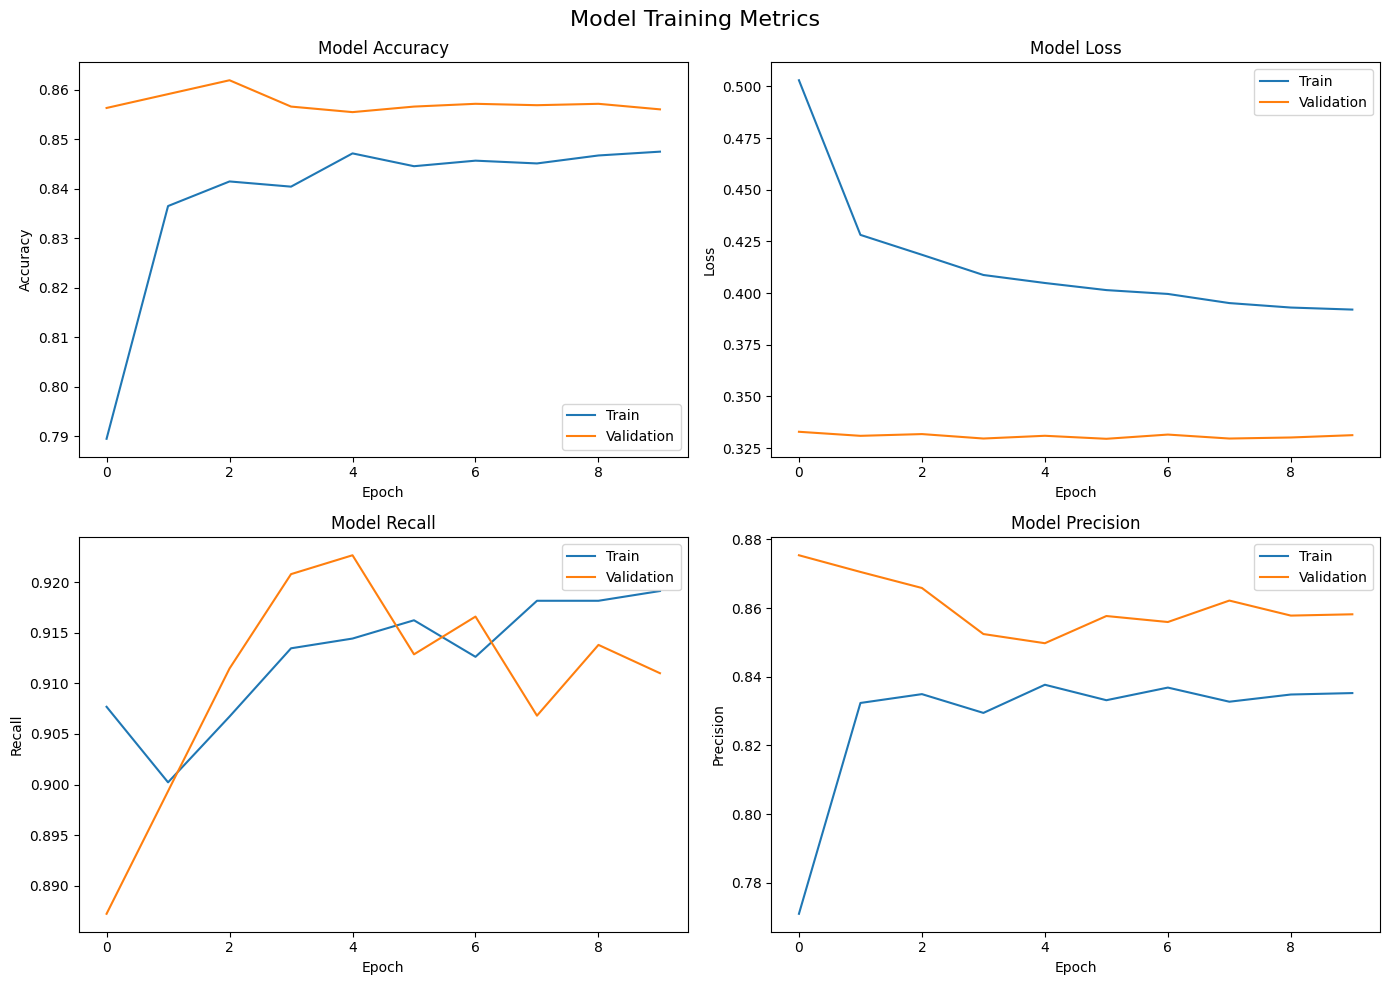

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'],     label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Loss
axes[0, 1].plot(history.history['loss'],     label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Recall
axes[1, 0].plot(history.history['recall'],     label='Train')
axes[1, 0].plot(history.history['val_recall'], label='Validation')
axes[1, 0].set_title('Model Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()

# Precision
axes[1, 1].plot(history.history['precision'],     label='Train')
axes[1, 1].plot(history.history['val_precision'], label='Validation')
axes[1, 1].set_title('Model Precision')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

plt.suptitle('Model Training Metrics', fontsize=16)
plt.tight_layout()
plt.savefig('./assets/real_training_metrics.png')
plt.show()

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step


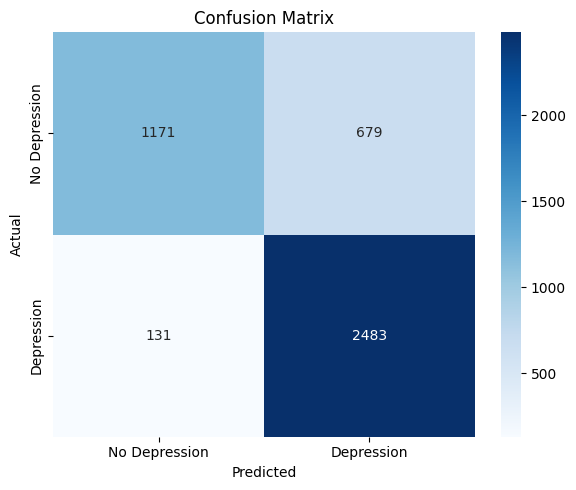

In [26]:
import seaborn as sns

y_pred = (model.predict(X_test) > 0.35).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('./assets/real_confusion_matrix.png')
plt.show()

In [27]:
report = classification_report(
    y_test,
    y_pred,
    target_names=['No Depression', 'Depression'],
    output_dict=True
)

# Convert to DataFrame
metrics_df = pd.DataFrame(report).transpose()

# Rename columns for clarity
metrics_df = metrics_df.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1-Score',
})

print(metrics_df[['Precision', 'Recall', 'F1-Score']].round(3))

               Precision  Recall  F1-Score
No Depression      0.899   0.633     0.743
Depression         0.785   0.950     0.860
accuracy           0.819   0.819     0.819
macro avg          0.842   0.791     0.801
weighted avg       0.833   0.819     0.811


In [28]:
model.save('./model/depression_model.h5')

Youden Threshold:        0.6974
TPR (Recall) at optimal: 0.8263
FPR at optimal:          0.1481

Recall-Optimized Threshold (>= 0.95):
  Threshold: 0.3461
  Recall:    0.9507
  FPR:       0.3670


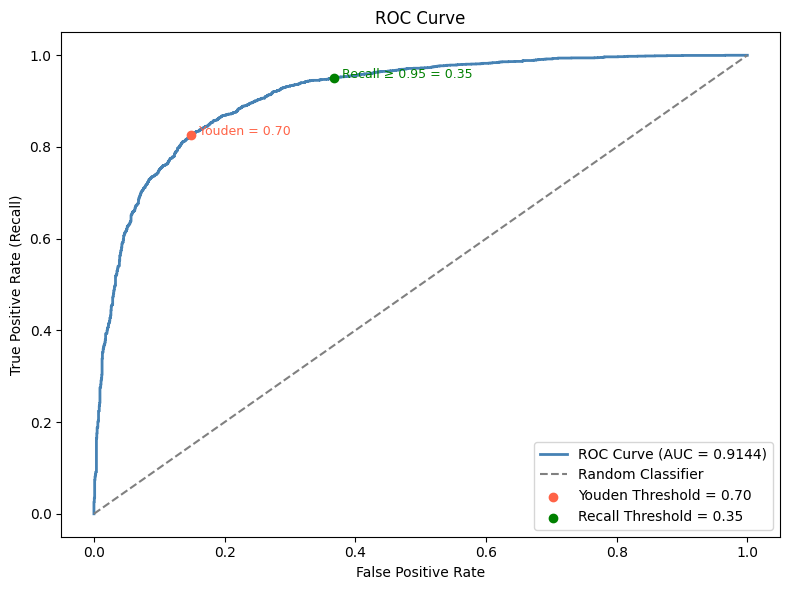

In [ ]:
from sklearn.metrics import roc_curve, auc

y_proba = model.predict(X_test, verbose=0).flatten()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

j_scores          = tpr - fpr
optimal_idx       = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_tpr       = tpr[optimal_idx]
optimal_fpr       = fpr[optimal_idx]

print(f"Youden Threshold:        {optimal_threshold:.4f}")
print(f"TPR (Recall) at optimal: {optimal_tpr:.4f}")
print(f"FPR at optimal:          {optimal_fpr:.4f}")

target_recall    = 0.95
mask             = tpr >= target_recall
valid_thresholds = thresholds[mask]
valid_tpr        = tpr[mask]
valid_fpr        = fpr[mask]

recall_optimal_threshold = valid_thresholds[np.argmax(valid_thresholds)]
recall_optimal_tpr       = valid_tpr[np.argmax(valid_thresholds)]
recall_optimal_fpr       = valid_fpr[np.argmax(valid_thresholds)]

print(f"\nRecall-Optimized Threshold (>= {target_recall}):")
print(f"  Threshold: {recall_optimal_threshold:.4f}")
print(f"  Recall:    {recall_optimal_tpr:.4f}")
print(f"  FPR:       {recall_optimal_fpr:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')

plt.scatter(optimal_fpr, optimal_tpr, color='tomato', zorder=5,
            label=f'Youden Threshold = {optimal_threshold:.2f}')
plt.annotate(f'  Youden = {optimal_threshold:.2f}',
             xy=(optimal_fpr, optimal_tpr), fontsize=9, color='tomato')

plt.scatter(recall_optimal_fpr, recall_optimal_tpr, color='green', zorder=5,
            label=f'Recall Threshold = {recall_optimal_threshold:.2f}')
plt.annotate(f'  Recall ≥ {target_recall} = {recall_optimal_threshold:.2f}',
             xy=(recall_optimal_fpr, recall_optimal_tpr), fontsize=9, color='green')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./assets/roc_curve.png')
plt.show()

y_pred_recall  = (y_proba > recall_optimal_threshold).astype(int)
report_recall  = classification_report(y_test, y_pred_recall, target_names=['No Depression', 'Depression'], output_dict=True)
cm_recall      = confusion_matrix(y_test, y_pred_recall)
tn, fp, fn, tp = cm_recall.ravel()